In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

from fastai.vision.all import *

# Reproducibility (score-neutral stability)
set_seed(42, reproducible=True)



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Prefer Kaggle-standard absolute paths
DATA_ROOT = Path("/kaggle/input/cassava-leaf-disease-classification")
train_data = DATA_ROOT / "train_images"
test_data = DATA_ROOT / "test_images"

assert train_data.exists(), f"Missing train_images at {train_data}"
assert test_data.exists(), f"Missing test_images at {test_data}"



In [3]:
df = pd.read_csv(DATA_ROOT / "train.csv")
df.head()



,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [4]:
fns_train = get_image_files(train_data)
fns_test = get_image_files(test_data)

len(fns_train), len(fns_test)



(18721, 2676)

In [5]:
# Quick sanity check: train.csv image_ids exist
missing = [fn for fn in df["image_id"].head(50) if not (train_data / fn).exists()]
missing[:5], len(missing)



([], 0)

In [6]:
# Fix tuple bug: trailing comma would make item_tfms a tuple-of-one, which is OK in fastai,
# but keep it explicit and consistent.
item_tfms = RandomResizedCrop(460, min_scale=0.75)
batch_tfms = [
    *aug_transforms(size=224, max_warp=0, max_zoom=0.8),
    Normalize.from_stats(*imagenet_stats),
]



In [7]:
# Keep your DataBlock core logic (ImageBlock + CategoryBlock from train.csv)
cassava = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader("image_id", pref=train_data),
    get_y=ColReader("label"),
    splitter=RandomSplitter(seed=42),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)



In [8]:
# This can be slow; keep but do not fail if summary has issues in some environments
try:
    cassava.summary(df)
except Exception as e:
    print(f"DataBlock summary skipped due to: {type(e).__name__}: {e}")



Setting-up type transforms pipelines
0      1000015157.jpg      0
1      1000201771.jpg      3
2       100042118.jpg      1
3      1000723321.jpg      1
4      1000812911.jpg      3
...               ...    ...
18716   999068805.jpg      3
18717   999329392.jpg      3
18718   999474432.jpg      1
18719   999616605.jpg      4
18720   999998473.jpg      4

[18721 rows x 2 columns]
Found 18721 items
2 datasets of sizes 14977,3744
Setting up Pipeline: ColReader -- {'cols': 'image_id', 'pref': Path('/kaggle/input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 -> PILBase.create
Setting up Pipeline: ColReader -- {'cols': 'label', 'pref': '', 'suff': '', 'label_delim': None}
 -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: ColReader -- {'cols': 'image_id', 'pref': Path('/kaggle/input/cassava-leaf-disease-classification/train_images'), 'suff': '', 'label_delim': None}
 -> PILBase.create
    starting from
  

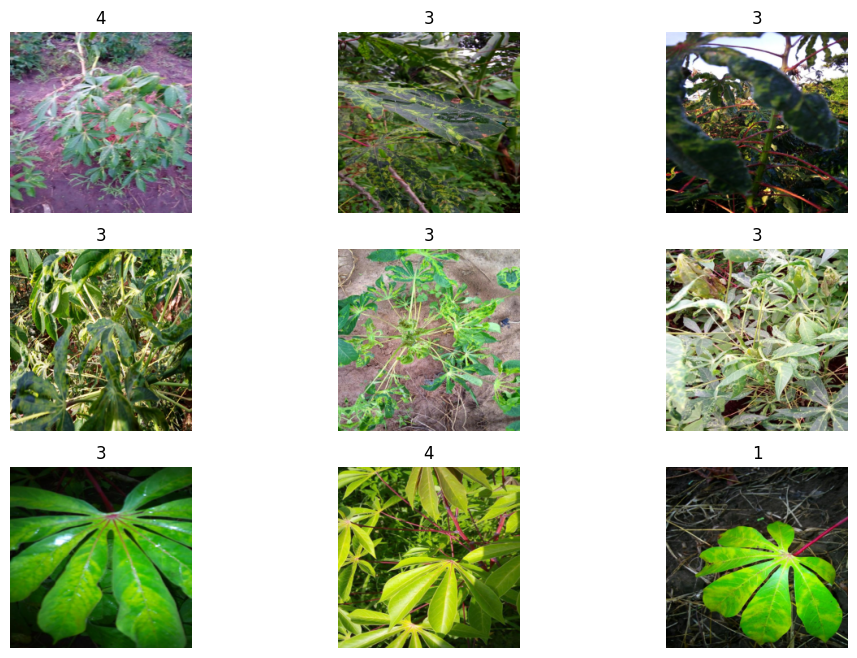

In [9]:
train_dls = cassava.dataloaders(df, bs=32, num_workers=2)
train_dls.show_batch(figsize=(12, 8), max_n=9)



In [10]:
# BUGFIX: export.pkl path doesn't exist; train a learner instead (minimal functional replacement).
# Core approach remains fastai vision classifier; no custom architecture introduced beyond a standard backbone.
learn = vision_learner(train_dls, resnet34, metrics=accuracy)
learn.fine_tune(3)



Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 102MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,1.056181,0.804702,0.715278,01:42


epoch,train_loss,valid_loss,accuracy,time
0,0.702716,0.600026,0.779915,01:02
1,0.555141,0.504302,0.823985,01:04
2,0.442414,0.468738,0.832532,01:05


In [11]:
test_dl = train_dls.test_dl(fns_test, with_labels=False)



In [12]:
# Get predictions and convert to class indices (int) for submission
probs, _ = learn.get_preds(dl=test_dl)
test_pred_idx = probs.argmax(dim=1).cpu().numpy().astype(int)
test_pred_idx[:10], probs.shape



(array([3, 3, 4, 3, 1, 0, 3, 4, 3, 1]), torch.Size([2676, 5]))

In [13]:
sample_sub = pd.read_csv(DATA_ROOT / "sample_submission.csv")
sample_sub.head(), sample_sub.shape



(         image_id  label
 0  1234294272.jpg      4
 1  1234332763.jpg      4
 2  1234375577.jpg      4
 3  1234555380.jpg      4
 4  1234571117.jpg      4,
 (2676, 2))

In [14]:
# Build submission in the exact required format: image_id,label
# Ensure order matches sample_submission.csv (Kaggle expects exactly those ids).
# Create mapping from filename -> prediction.
test_files = [Path(o).name for o in test_dl.items]
pred_map = dict(zip(test_files, test_pred_idx))

# Fill in using sample submission order; fallback to 0 if any mismatch (shouldn't happen)
sub = sample_sub.copy()
sub["label"] = sub["image_id"].map(pred_map).fillna(0).astype(int)

# Final sanity checks
assert list(sub.columns) == ["image_id", "label"]
assert sub["image_id"].nunique() == len(sub)
assert sub["label"].between(0, 4).all()

sub.head(), sub["label"].value_counts().sort_index()



(         image_id  label
 0  1234294272.jpg      3
 1  1234332763.jpg      3
 2  1234375577.jpg      1
 3  1234555380.jpg      1
 4  1234571117.jpg      3,
 label
 0     123
 1     258
 2     244
 3    1685
 4     366
 Name: count, dtype: int64)

In [15]:
# Write submission
out_path = Path("submission.csv")
sub.to_csv(out_path, index=False)
print(f"Wrote {out_path.resolve()} with shape {sub.shape}")

Wrote /kaggle/working/submission.csv with shape (2676, 2)
